In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import zipfile

zip_path = "/content/drive/MyDrive/Project_Dataset.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [16]:
import os

os.listdir("/content/dataset")

['seg_train', 'seg_pred', 'seg_test']

In [17]:
import os

train_path = "/content/dataset/seg_train/seg_train"

os.listdir(train_path)

['forest', 'sea', 'buildings', 'mountain', 'street', 'glacier']

In [18]:
import os

train_path = "/content/dataset/seg_train/seg_train"

classes = os.listdir(train_path)

for c in classes:
    print(c, len(os.listdir(os.path.join(train_path, c))))

forest 2271
sea 2274
buildings 2191
mountain 2512
street 2382
glacier 2404


In [19]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_path = "/content/dataset/seg_train/seg_train"

# ResNet50 standard preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Load full dataset
full_dataset = datasets.ImageFolder(train_path, transform=transform)

print("Classes:", full_dataset.classes)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [20]:
from torch.utils.data import random_split

# 80% train, 20% validation split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 11227
Validation samples: 2807


In [21]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully")

DataLoaders created successfully


In [22]:
import torch
import torch.nn as nn
from torchvision import models

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze base model layers (feature extractor)
for param in model.parameters():
    param.requires_grad = False

# Replace final classification layer (6 classes)
model.fc = nn.Linear(model.fc.in_features, 6)

# Move model to device (GPU/CPU)
model = model.to(device)

print("Model is ready!")


Using device: cuda
Model is ready!


In [23]:
!pip install tqdm

In [24]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Update progress bar
        loop.set_postfix(loss=loss.item(), acc=100*correct/total)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print("-" * 40)

Epoch 1/5: 100%|██████████| 351/351 [01:08<00:00,  5.14it/s, acc=85.3, loss=0.474]



Epoch 1/5
Train Loss: 0.4840, Train Acc: 85.30%
Val Loss: 0.2843, Val Acc: 91.06%
----------------------------------------


Epoch 2/5: 100%|██████████| 351/351 [01:02<00:00,  5.64it/s, acc=90.5, loss=0.297]



Epoch 2/5
Train Loss: 0.2827, Train Acc: 90.51%
Val Loss: 0.2466, Val Acc: 91.98%
----------------------------------------


Epoch 3/5: 100%|██████████| 351/351 [01:02<00:00,  5.66it/s, acc=91.5, loss=0.393]



Epoch 3/5
Train Loss: 0.2455, Train Acc: 91.54%
Val Loss: 0.2390, Val Acc: 91.81%
----------------------------------------


Epoch 4/5: 100%|██████████| 351/351 [01:02<00:00,  5.64it/s, acc=92.4, loss=0.41]



Epoch 4/5
Train Loss: 0.2245, Train Acc: 92.36%
Val Loss: 0.2328, Val Acc: 92.27%
----------------------------------------


Epoch 5/5: 100%|██████████| 351/351 [01:01<00:00,  5.70it/s, acc=92.6, loss=0.312]



Epoch 5/5
Train Loss: 0.2122, Train Acc: 92.58%
Val Loss: 0.2313, Val Acc: 92.34%
----------------------------------------


In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    "/content/dataset/seg_test/seg_test",
    transform=transform
)


test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test loader ready")

Test loader ready


In [29]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print(f"🔥 Final Test Accuracy: {test_acc:.2f}%")

🔥 Final Test Accuracy: 91.20%


In [34]:
class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

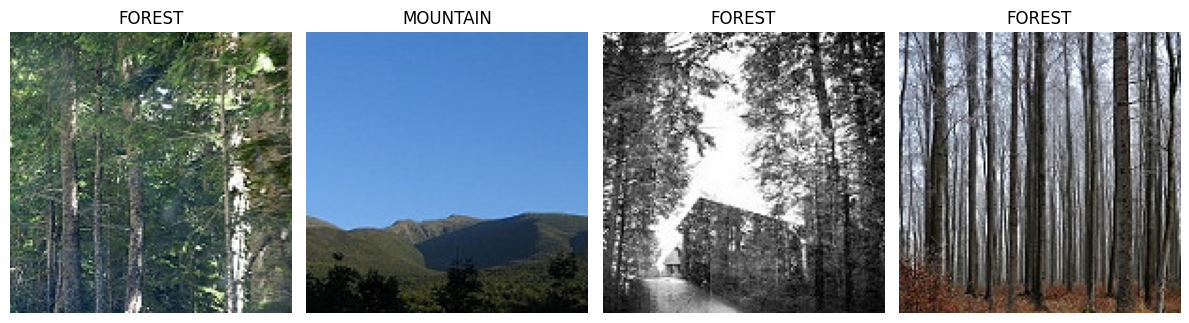

In [35]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch

class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

pred_dir = "/content/dataset/seg_pred/seg_pred/"
sample_files = os.listdir(pred_dir)[:4]
sample_paths = [os.path.join(pred_dir, f) for f in sample_files]

model.eval()
plt.figure(figsize=(12, 6))

for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_class = class_names[pred.item()]

    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class.upper()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
model_filename = "landscape_resnet50.pth"
torch.save(model.state_dict(), model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as landscape_resnet50.pth


In [38]:
import json

class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

with open("classes.json", "w") as f:
    json.dump(class_names, f)

In [39]:
# Development Phase: Task 2

%%writefile Train.py
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

def train_model():
    # 1. Setup Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 2. Data Transformations
    transform = transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 3. Fast Local Dataset Paths
    train_dir = '/content/local_dataset/seg_train/seg_train'

    if not os.path.exists(train_dir):
        print(f"Error: Training directory {train_dir} not found. Please extract your dataset first.")
        return

    train_data = datasets.ImageFolder(root=train_dir, transform=transform)
    train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

    # 4. Load Pretrained ResNet-50 & Freeze Base Layers
    print("Loading pretrained ResNet-50...")
    model = models.resnet50(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False

    # Replace final fully connected layer (6 output categories)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 6)
    model = model.to(device)

    # 5. Define Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

    # 6. Training Loop (Running 3 quick epochs for verification)
    epochs = 3
    print("Starting model training script...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        end_time = time.time()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100.*correct/total:.2f}% | Time: {end_time-start_time:.2f}s")

    # 7. Save Weights
    torch.save(model.state_dict(), 'landscape_resnet50.pth')
    print("Model training complete. Saved weights to 'landscape_resnet50.pth'")

if __name__ == '__main__':
    train_model()

Writing Train.py


In [40]:
%%writefile Inference.py

import os
import sys
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

# Class labels
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

def load_model(weights_path):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 6)

    model.load_state_dict(torch.load(weights_path, map_location=device))

    model = model.to(device)
    model.eval()

    return model, device


def predict_image(image_path, model, device):

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return CLASS_NAMES[pred.item()]


if __name__ == "__main__":

    if len(sys.argv) < 2:
        print("Usage: python Inference.py <image_path>")
        sys.exit(1)

    image_path = sys.argv[1]

    model, device = load_model("landscape_resnet50.pth")

    result = predict_image(image_path, model, device)

    print("Prediction:", result.upper())

Writing Inference.py


In [41]:
%%writefile app.py

import os
import torch
import torch.nn as nn
from flask import Flask, request, jsonify
from torchvision import transforms, models
from PIL import Image
import io

app = Flask(__name__)

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
WEIGHTS_PATH = 'landscape_resnet50.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model():

    if not os.path.exists(WEIGHTS_PATH):
        raise FileNotFoundError("Model weights not found!")

    model = models.resnet50()
    model.fc = nn.Linear(model.fc.in_features, 6)

    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))

    model = model.to(device)
    model.eval()
    return model

model = load_model()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

@app.route('/predict', methods=['POST'])
def predict():

    if 'file' not in request.files:
        return jsonify({'error': 'No file provided'}), 400

    file = request.files['file']

    image = Image.open(io.BytesIO(file.read())).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return jsonify({
        'prediction': CLASS_NAMES[pred.item()].upper()
    })

@app.route('/', methods=['GET'])
def home():
    return jsonify({
        'message': 'Flask API running',
        'endpoint': '/predict'
    })

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)

Writing app.py


In [1]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app

RUN pip install torch torchvision flask pillow

COPY app.py /app/
COPY landscape_resnet50.pth /app/

EXPOSE 5000

CMD ["python", "app.py"]

Writing Dockerfile
